In [ ]:
import pandas as pd
import numpy as np
import json
import pickle

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
sales = pd.read_csv("sl_retail_sales_2024.csv")
weather = pd.read_csv("weather_2024.csv")
events = pd.read_csv("events_2024.csv")

In [ ]:
print("Sales:")
print(sales.head())

print("\nWeather:")
print(weather.head())

print("\nEvents:")
print(events.head())

Sales:
         date store_id store_name product_id product_name     category  \
0  01/01/2024     S001   Nugegoda       P001      T-shirt     Clothing   
1  01/01/2024     S001   Nugegoda       P002        Jeans     Clothing   
2  01/01/2024     S001   Nugegoda       P003       Jacket     Clothing   
3  01/01/2024     S001   Nugegoda       P004        Shoes     Footwear   
4  01/01/2024     S001   Nugegoda       P005          Cap  Accessories   

   units_sold  price_lkr  discount day_of_week  
0          17       2500       0.2      Monday  
1          11       5500       0.2      Monday  
2           5       8500       0.2      Monday  
3           9       7500       0.2      Monday  
4          22       1200       0.2      Monday  

Weather:
         date  temperature  rainfall  humidity weather_condition
0  01/01/2024         30.6       0.0        76             Sunny
1  02/01/2024         33.0       0.0        66             Sunny
2  03/01/2024         30.8       0.0        73   

In [ ]:
sales['date'] = pd.to_datetime(sales['date'], dayfirst=True)
weather['date'] = pd.to_datetime(weather['date'], dayfirst=True)
events['date'] = pd.to_datetime(events['date'], dayfirst=True)

In [ ]:
print("Sales:")
print(sales.head())

Sales:
        date store_id store_name product_id product_name     category  \
0 2024-01-01     S001   Nugegoda       P001      T-shirt     Clothing   
1 2024-01-01     S001   Nugegoda       P002        Jeans     Clothing   
2 2024-01-01     S001   Nugegoda       P003       Jacket     Clothing   
3 2024-01-01     S001   Nugegoda       P004        Shoes     Footwear   
4 2024-01-01     S001   Nugegoda       P005          Cap  Accessories   

   units_sold  price_lkr  discount day_of_week  
0          17       2500       0.2      Monday  
1          11       5500       0.2      Monday  
2           5       8500       0.2      Monday  
3           9       7500       0.2      Monday  
4          22       1200       0.2      Monday  


In [ ]:
sales['date'] = pd.to_datetime(sales['date'], dayfirst=True)
weather['date'] = pd.to_datetime(weather['date'], dayfirst=True)
events['date'] = pd.to_datetime(events['date'], dayfirst=True)

In [ ]:
events = events.groupby('date').agg({
    'event_type': lambda x: ','.join(sorted(set(x.astype(str)))),
    'is_holiday': 'max'
}).reset_index()

In [ ]:
events = events.groupby('date').agg({
    'event_type': lambda x: ','.join(sorted(set(x.astype(str)))),
    'is_holiday': 'max'
}).reset_index()

In [ ]:
print(events.head(10))

        date         event_type  is_holiday
0 2024-01-01  Holiday,Promotion           1
1 2024-01-05      School_Season           0
2 2024-01-15            Holiday           1
3 2024-01-25            Holiday           1
4 2024-02-04            Holiday           1
5 2024-02-10          Promotion           0
6 2024-02-23            Holiday           1
7 2024-03-08            Holiday           1
8 2024-03-24            Holiday           1
9 2024-03-25          Promotion           0


In [ ]:
data = sales.merge(weather, on='date', how='left')
data = data.merge(events[['date', 'event_type', 'is_holiday']], on='date', how='left')

In [ ]:
data['event_type'] = data['event_type'].fillna("None")
data['is_holiday'] = data['is_holiday'].fillna(0)

In [ ]:
print(data.head())
print(data.columns)
print(data.shape)

        date store_id store_name product_id product_name     category  \
0 2024-01-01     S001   Nugegoda       P001      T-shirt     Clothing   
1 2024-01-01     S001   Nugegoda       P002        Jeans     Clothing   
2 2024-01-01     S001   Nugegoda       P003       Jacket     Clothing   
3 2024-01-01     S001   Nugegoda       P004        Shoes     Footwear   
4 2024-01-01     S001   Nugegoda       P005          Cap  Accessories   

   units_sold  price_lkr  discount day_of_week  temperature  rainfall  \
0          17       2500       0.2      Monday         30.6       0.0   
1          11       5500       0.2      Monday         30.6       0.0   
2           5       8500       0.2      Monday         30.6       0.0   
3           9       7500       0.2      Monday         30.6       0.0   
4          22       1200       0.2      Monday         30.6       0.0   

   humidity weather_condition         event_type  is_holiday  
0        76             Sunny  Holiday,Promotion         1.

In [ ]:
data['is_promotion'] = data['event_type'].str.contains('Promotion', case=False, na=False).astype(int)
data['is_school'] = data['event_type'].str.contains('School', case=False, na=False).astype(int)
data['is_festival'] = data['event_type'].str.contains('Festival', case=False, na=False).astype(int)

In [ ]:
data = data.sort_values(['store_id', 'product_id', 'date']).reset_index(drop=True)

In [ ]:
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day
data['day_of_week_num'] = data['date'].dt.dayofweek  # Monday=0, Sunday=6

In [ ]:
data['lag_1'] = data.groupby(['store_id', 'product_id'])['units_sold'].shift(1)
data['lag_7'] = data.groupby(['store_id', 'product_id'])['units_sold'].shift(7)

In [ ]:
data['rolling_mean_7'] = (
    data.groupby(['store_id', 'product_id'])['units_sold']
    .shift(1)
    .rolling(7)
    .mean()
)

In [ ]:
data['rain_accessory'] = data['rainfall'] * (data['category'] == 'Accessories').astype(int)

In [ ]:
data = data.dropna().reset_index(drop=True)

In [ ]:
print(data.shape)
print(data.head())

(8616, 26)
        date store_id store_name product_id product_name  category  \
0 2024-01-08     S001   Nugegoda       P001      T-shirt  Clothing   
1 2024-01-09     S001   Nugegoda       P001      T-shirt  Clothing   
2 2024-01-10     S001   Nugegoda       P001      T-shirt  Clothing   
3 2024-01-11     S001   Nugegoda       P001      T-shirt  Clothing   
4 2024-01-12     S001   Nugegoda       P001      T-shirt  Clothing   

   units_sold  price_lkr  discount day_of_week  ...  is_promotion  is_school  \
0          12       2500       0.0      Monday  ...             0          0   
1          18       2500       0.0     Tuesday  ...             0          0   
2          17       2500       0.0   Wednesday  ...             0          0   
3          24       2500       0.2    Thursday  ...             0          0   
4          19       2500       0.0      Friday  ...             0          0   

   is_festival month day  day_of_week_num  lag_1  lag_7  rolling_mean_7  \
0           

In [ ]:
X = data[[
    'price_lkr',
    'discount',
    'temperature',
    'rainfall',
    'humidity',
    'month',
    'day',
    'day_of_week_num',
    'lag_1',
    'lag_7',
    'rolling_mean_7',
    'is_holiday',
    'is_promotion',
    'is_school',
    'is_festival',
    'rain_accessory'
]]

In [ ]:
X = pd.concat([
    X,
    pd.get_dummies(data['product_id'], prefix='product'),
    pd.get_dummies(data['category'], prefix='cat'),
    pd.get_dummies(data['store_id'], prefix='store'),
    pd.get_dummies(data['weather_condition'], prefix='weather')
], axis=1)

In [ ]:
y = data['units_sold']

In [ ]:
print(X.head())
print(X.shape)
print(X.select_dtypes(include=['object']).columns)

   price_lkr  discount  temperature  rainfall  humidity  month  day  \
0       2500       0.0         30.3       0.0        71      1    8   
1       2500       0.0         30.8       0.0        67      1    9   
2       2500       0.0         30.8       0.0        69      1   10   
3       2500       0.2         30.7       0.0        71      1   11   
4       2500       0.0         29.2       5.6        85      1   12   

   day_of_week_num  lag_1  lag_7  ...  product_P008  cat_Accessories  \
0                0   17.0   17.0  ...         False            False   
1                1   12.0   17.0  ...         False            False   
2                2   18.0   18.0  ...         False            False   
3                3   17.0   18.0  ...         False            False   
4                4   24.0   18.0  ...         False            False   

   cat_Clothing  cat_Footwear  store_S001  store_S002  store_S003  \
0          True         False        True       False       False   
1 

In [ ]:
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [ ]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
preds = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("MAE:", mae)
print("R2:", r2)

MAE: 0.6920413970947266
R2: 0.9252763986587524


In [ ]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance.head(15))

            feature  importance
10   rolling_mean_7    0.328574
1          discount    0.282273
9             lag_7    0.111773
8             lag_1    0.027825
21     product_P006    0.025961
22     product_P007    0.024620
24  cat_Accessories    0.021557
31    weather_Rainy    0.020495
28       store_S002    0.018178
25     cat_Clothing    0.017786
7   day_of_week_num    0.017375
27       store_S001    0.016193
16     product_P001    0.013442
6               day    0.013390
0         price_lkr    0.010391


In [ ]:
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("columns.json", "w") as f:
    json.dump(list(X.columns), f)

In [ ]:
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("columns.json", "w") as f:
    json.dump(list(X.columns), f)

In [ ]:
from google.colab import files
files.download("model.pkl")
files.download("columns.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
lr_model = LinearRegression()

rf_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
import pickle

pickle.dump(rf_model, open("rf_model.pkl", "wb"))
pickle.dump(lr_model, open("lr_model.pkl", "wb"))

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

#  Individual predictions
pred_xgb = model.predict(X_test)
pred_rf = rf_model.predict(X_test)
pred_lr = lr_model.predict(X_test)

#  Ensemble prediction (weighted)
pred_ensemble = (
    0.5 * pred_xgb +
    0.3 * pred_rf +
    0.2 * pred_lr
)

# -----------------------------
#  EVALUATE XGBOOST
# -----------------------------
mae_xgb = mean_absolute_error(y_test, pred_xgb)
r2_xgb = r2_score(y_test, pred_xgb)

print("🔵 XGBoost Results")
print("MAE:", mae_xgb)
print("R2 :", r2_xgb)

# -----------------------------
# 📊 EVALUATE ENSEMBLE
# -----------------------------
mae_ens = mean_absolute_error(y_test, pred_ensemble)
r2_ens = r2_score(y_test, pred_ensemble)

print("\n🔥 Ensemble Results")
print("MAE:", mae_ens)
print("R2 :", r2_ens)

# -----------------------------
# COMPARISON SUMMARY
# -----------------------------
print("\n📊 Improvement Comparison")

print("MAE Improvement:", mae_xgb - mae_ens)
print("R2 Improvement :", r2_ens - r2_xgb)

🔵 XGBoost Results
MAE: 0.6920413970947266
R2 : 0.9252763986587524

🔥 Ensemble Results
MAE: 0.7968717961511448
R2 : 0.9003285151870027

📊 Improvement Comparison
MAE Improvement: -0.10483039905641822
R2 Improvement : -0.0249478834717497


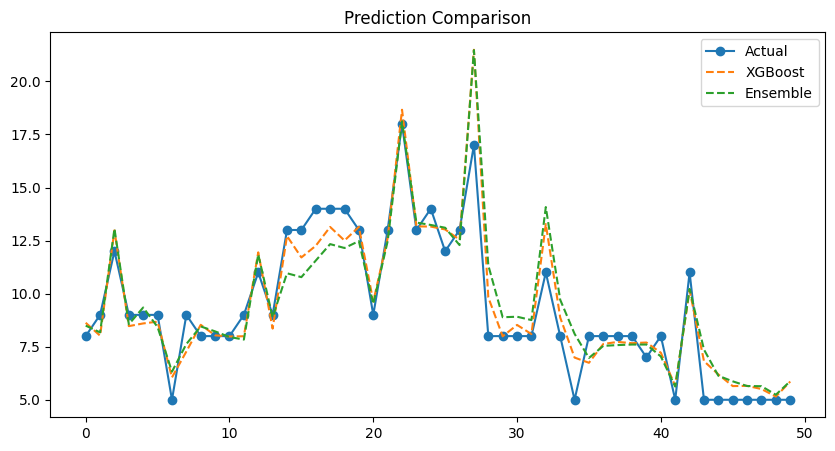

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label="Actual", marker='o')
plt.plot(pred_xgb[:50], label="XGBoost", linestyle='--')
plt.plot(pred_ensemble[:50], label="Ensemble", linestyle='--')

plt.legend()
plt.title("Prediction Comparison")
plt.show()